# Import Required Libraries
Import the necessary libraries, including the dataset loader from src/dataloaders/datasets/a_thaliana_dataset.py.

In [1]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch
from datasets import Dataset

# list of HyenaDNA pretrained models available in the hugging face hub
pretrained_models_max_length = {
    'hyenadna-tiny-1k-seqlen-hf': 1024,
        'hyenadna-small-32k-seqlen-hf': 32768,
        'hyenadna-medium-160k-seqlen-hf': 160000,
        'hyenadna-medium-450k-seqlen-hf': 450000,  # T4 up to here
        'hyenadna-large-1m-seqlen-hf': 1_000_000,
}
pretrained_model_name = 'hyenadna-small-32k-seqlen-hf'

# instantiate pretrained model
checkpoint = 'LongSafari/'+pretrained_model_name
tokenizer = AutoTokenizer.from_pretrained(checkpoint, trust_remote_code=True)

/home/lpedraza/anaconda3/envs/hyena-dna/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/lpedraza/anaconda3/envs/hyena-dna/lib/python3.8/site-packages/huggingface_hub/file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Explicitly passing a `revision` is encouraged when loading a model with custom code to ensure no malicious code has been contributed in a newer revision.


# Exploratory Data Analysis (EDA)
Load the dataset using the provided BED and FA files.

In [26]:
# Import the dataset loader
from src.dataloaders.datasets.a_thaliana_dataset import a_thalinana_Dataset

# Define the paths to the BED and FA files
bed_file_path = 'data/A.Thaliana/A.Thaliana.bed'
fa_file_path = 'data/A.Thaliana/TAIR10_mod.fna'

# Load the dataset using the provided BED and FA files
ds_test = a_thalinana_Dataset(bed_file=bed_file_path, 
                              fasta_file=fa_file_path, 
                              split='test', 
                              max_length = 2000,
                              tokenizer = tokenizer,
                              tokenizer_name='char',
                              replace_N_token = True
                              )

In [4]:
ds_test.label_dict

{'gene': 0, 'intergenic': 1}

In [30]:
seq_0 = str.join('',tokenizer.convert_ids_to_tokens(ds_test[0]['input_ids']))
print(seq_0)
print(len(seq_0))

TTCAGCTAGGAATTTTGTTATGAATCAGAACTCAGAAGGCTAATGAAAATCCAAATTGAACAACAACCGTATAAATAAATATGTCAATGTTGTTTGTTGGTAATTTATCAATAGGAGGAGAAACATTGATAGACAGACAATTCAAAATTGAACTAAACCAGAACTCAAAAGTCGGTTATAGCTTCACATTTAGCTTCCAATATCTTCACAGCTTCAGTGAAGAGAACCTCTGGAGGCAGTGATCCGGTGGACTCAATGTTAACTGAGAAAAAAGACGACAAGAAACTCAATTACGATATCTTTCAGATCATGAGTAGCAGAGTAAAAGGAATGGGTTTTATTTTTCTCTTCTTACATATAAAATGGTTCTTAACACTGCCAAGATCCACATGGTCTACCAAATCATCGTCTCTTACGCATTCCTTACACAATGTGCACTTACGTGGCTGCGCTACTGTTGCCCTTTTCTTACCTGTTTTCCACAAGTCAGTATGAAATCAAATTTAAGTAAGTCATGCAGCCAAGTTCATCAGCTTGCATAAGATTTTATACTTCACCTTTTCCCATGTCTTCAATGTCGAAAACATTCTGTGGGCAGACGTTTACAAGTCGTTCAGCAAGTTCATCCTCAACTTCCCCACGTAGAACCACCTAAGATAGTATAAACAAAAGCATTACGAAACATATATATTGGGATGAGGAAAGACAAAACAAAGAGCTGTTTCCCATAAAGCATATGATAGATTGATGTATATACTTCTCACCTCAGGATGCATTCTATACCAAGCAGTCCCTACTGGAGACCACTTTGCATGTGTTTTACCAATGCCCTTAACCGCATGAGCTTCGAGCTCGATTTCCTGGGAAAAAAGAGATAAAAGAAGATGCACATGTTTCATCTCTCATTGCAAGTATGGTCTGCTTGGGTGTATATAAAAAGAATGTACAGAAACACTACCTGACCAGGGGCGAGTTTTGCTATCAAGATATCGAGGTCGCA

### Display Dataset Information
Display basic information about the dataset, such as the number of entries and a preview of the data.

In [32]:
# Display basic information about the dataset
# Number of entries in the dataset
num_entries = len(ds_test)
print(f"Number of entries in the dataset: {num_entries}")

Number of entries in the dataset: 1222


In [31]:
seq_0 = tokenizer.convert_tokens_to_string(tokenizer.convert_ids_to_tokens(ds_test[-1]['input_ids']))
print(seq_0)
print(len(seq_0))

TGATTTGTTCAAATTCTACTCTTTGTAAACTTTCTTGTCTACATGTTTTGAAAGCCAGGCAGTTTTCTTTTATTTATTTAACTTGTGTACACCACTTGCTTTTTCATAGATCATTTTTTGATACAATTAAAAGCAAAGGAAGTGAGAAGAGATTCTTTGTAGATTTGACGATGAGTTCAAGAATTAGAACCTGTATGCTCCTGATCTTGTTTTTCTTCCAAAAATGTTATGTTTCTGCACTCACTAATGTTTTCGACGGTACGTATATAGATGATGGTTAGGGTTTTTCTGATATAAGAATTTCTAAATCATTGAATTATTTATAACCTAGTGCAGCTTCTGCTTTAAGAGGTATGAAGAATGAATGGACCAGGTCTCCGAAAGGTTGGGAAGGCTCTGACCCTTGCGGAACCAATTGGGTTGGAATTACATGTACCAATGACCGCGTCGTGTCAATGTAACAACTTTTATTTTTTATTTTTCCAGCTTCTTCCATTTAATTCTTTGCAGAGTTCTAACGATATGATGTTGGTTGCAGATCACTAGTTAACCACAATTTGGAAGGAACGCTTTCTGAGTATATTTTAGCCTTGTCAGAATTGGAAATCTTGTAAGTCTTTTTCTTCATCTTCCCATACAAGAAATGGATGTTGTTCTCATCATATGATCCAATGTTTTAGAGATTTATCATTCAATATTGGATTGACTGGACCACTTCCATCCAACATTGGTGACCTTAAGAAGTTAAAGAATTTGTAAGCAAACATTATCATGCATGACCCATTTGTAACATCCTTTTTCTATTGCATATCTTAAACTAACTATCTTTCACTCTCCAGGATCCTTGTGGGATGTGGTCTTAGTGGTCAAATCCCTGATTCTATAGGATCTCTAGAACAAATTATAAATCTGTAAGATTTTGTTGCTTCAAGTTATTATAAATAGTCTATTTTTCAATTGTAGTCTAAATAACCATTAAATCATCTTCAATGTATTTTTC

In [2]:
from Bio import SeqIO

def find_sequence_in_fasta(fasta_file, query_sequence):
    seq_len = len(query_sequence)
    # Cargar el archivo FASTA
    for record in SeqIO.parse(fasta_file, "fasta"):
        sequence = str(record.seq)
        sequence = sequence.upper() # Convertir a mayúsculas
        reverse_complement_seq = str(record.seq.reverse_complement())
        chr_len = len(sequence)

        # Buscar la secuencia directa
        if query_sequence in sequence:
            start = sequence.find(query_sequence)
            end = start + seq_len
            print(f"Secuencia encontrada en {record.id} (strand +) en la posición: {start}")
            print(f"{record.id}, seq in strand +: {sequence[start: end]}")
            return (record.id, start, end, '+')

        # Buscar el reverse complement
        if query_sequence in reverse_complement_seq:
            end = chr_len - reverse_complement_seq.find(query_sequence)
            start = end - seq_len
            print(f"Secuencia encontrada en {record.id} (strand -) en la posición: {start} del strand +")
            print(f"{record.id}, seq in strand +: {reverse_complement_seq[start: end]}")
            return (record.id, start, end, '-')

    print("Secuencia no encontrada en el archivo FASTA.")
    return None

In [ ]:
# Esta implementación rompe el kernel del jupyter notebook
from Bio import SeqIO
from Bio import pairwise2
from Bio.pairwise2 import format_alignment

def find_subsequence_in_fasta(fasta_file, query_sequence, min_score=50, match = 2, mismatch = -1, gap_open = -0.5, gap_extend = -0.1):
    # Cargar el archivo FASTA
    for record in SeqIO.parse(fasta_file, "fasta"):
        sequence = str(record.seq).upper()  # Convertir a mayúsculas
        reverse_complement_seq = str(record.seq.reverse_complement()).upper()

        # Alinear la query_sequence con la secuencia directa
        alignments = pairwise2.align.localms(sequence, query_sequence, match, mismatch, gap_open, gap_extend)
        if alignments and alignments[0].score >= min_score:
            alignment = alignments[0]
            start = alignment.start
            end = alignment.end
            print(f"Secuencia encontrada en {record.id} (strand +) en la posición: {start}")
            print(format_alignment(*alignment))
            return (record.id, start, end, '+')

        # Alinear la query_sequence con el reverse complement
        alignments = pairwise2.align.localms(reverse_complement_seq, query_sequence, match, mismatch, gap_open, gap_extend)
        if alignments and alignments[0].score >= min_score:
            alignment = alignments[0]
            start = len(sequence) - alignment.end
            end = len(sequence) - alignment.start
            print(f"Secuencia encontrada en {record.id} (strand -) en la posición: {start} del strand +")
            print(format_alignment(*alignment))
            return (record.id, start, end, '-')

    print("Secuencia no encontrada en el archivo FASTA.")
    return None

In [34]:
# Buscar la secuencia
result = find_sequence_in_fasta(fasta_file=fa_file_path, query_sequence=seq_0)
if result:
    chr, start, end, strand = result
    print(f"Coordenadas: chr={chr}, start={start}, end={end}, strand={strand}")

Secuencia encontrada en Chr5 (strand +) en la posición: 20210878
Chr5, seq in strand +: TGATTTGTTCAAATTCTACTCTTTGTAAACTTTCTTGTCTACATGTTTTGAAAGCCAGGCAGTTTTCTTTTATTTATTTAACTTGTGTACACCACTTGCTTTTTCATAGATCATTTTTTGATACAATTAAAAGCAAAGGAAGTGAGAAGAGATTCTTTGTAGATTTGACGATGAGTTCAAGAATTAGAACCTGTATGCTCCTGATCTTGTTTTTCTTCCAAAAATGTTATGTTTCTGCACTCACTAATGTTTTCGACGGTACGTATATAGATGATGGTTAGGGTTTTTCTGATATAAGAATTTCTAAATCATTGAATTATTTATAACCTAGTGCAGCTTCTGCTTTAAGAGGTATGAAGAATGAATGGACCAGGTCTCCGAAAGGTTGGGAAGGCTCTGACCCTTGCGGAACCAATTGGGTTGGAATTACATGTACCAATGACCGCGTCGTGTCAATGTAACAACTTTTATTTTTTATTTTTCCAGCTTCTTCCATTTAATTCTTTGCAGAGTTCTAACGATATGATGTTGGTTGCAGATCACTAGTTAACCACAATTTGGAAGGAACGCTTTCTGAGTATATTTTAGCCTTGTCAGAATTGGAAATCTTGTAAGTCTTTTTCTTCATCTTCCCATACAAGAAATGGATGTTGTTCTCATCATATGATCCAATGTTTTAGAGATTTATCATTCAATATTGGATTGACTGGACCACTTCCATCCAACATTGGTGACCTTAAGAAGTTAAAGAATTTGTAAGCAAACATTATCATGCATGACCCATTTGTAACATCCTTTTTCTATTGCATATCTTAAACTAACTATCTTTCACTCTCCAGGATCCTTGTGGGATGTGGTCTTAGTGGTCAAATCCCTGATTCTATAGGATCTCTAGAACAAATTATAAATCTG

In [44]:
import pandas as pd

# carga el archivo A_Thaliana.bed en un dataframe
df = pd.read_csv(bed_file_path, sep='\t', header=None)
df.columns = ['chr', 'start', 'end', 'label', 'split', 'strand']
df.head()

,chr,start,end,label,split,strand
0,chr1,50000,50100,gene,2,-
1,chr2,519826,525528,intergenic,0,.
2,chr1,756262,757300,intergenic,2,-
3,chr4,759357,768230,intergenic,2,.
4,chr5,723043,723288,gene,1,+


## Train HyenaDNA with gene-intergen dataset

In [11]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch

# instantiate pretrained model
pretrained_model_name = 'hyenadna-small-32k-seqlen-hf'
checkpoint = 'LongSafari/'+pretrained_model_name
tokenizer = AutoTokenizer.from_pretrained(checkpoint, trust_remote_code=True)
model  = AutoModelForSequenceClassification.from_pretrained(checkpoint, torch_dtype=torch.bfloat16, device_map="auto", trust_remote_code=True)

Explicitly passing a `revision` is encouraged when loading a model with custom code to ensure no malicious code has been contributed in a newer revision.
loading file added_tokens.json from cache at None
loading file special_tokens_map.json from cache at /home/lpedraza/.cache/huggingface/hub/models--LongSafari--hyenadna-small-32k-seqlen-hf/snapshots/8fe770c78eb13fe33bf81501612faeddf4d6f331/special_tokens_map.json
loading file tokenizer_config.json from cache at /home/lpedraza/.cache/huggingface/hub/models--LongSafari--hyenadna-small-32k-seqlen-hf/snapshots/8fe770c78eb13fe33bf81501612faeddf4d6f331/tokenizer_config.json
loading configuration file config.json from cache at /home/lpedraza/.cache/huggingface/hub/models--LongSafari--hyenadna-small-32k-seqlen-hf/snapshots/8fe770c78eb13fe33bf81501612faeddf4d6f331/config.json
Explicitly passing a `revision` is encouraged when loading a configuration with custom code to ensure no malicious code has been contributed in a newer revision.
loading c

### Data loading

In [3]:
# Experiment settings:

# Define the paths to the BED and FA files
bed_file_path = 'data/A.Thaliana/A.Thaliana.bed'
fa_file_path = 'data/A.Thaliana/TAIR10_mod.fna'
# Other dataset settings
use_padding = True
rc_aug = True  # reverse complement augmentation
rand_aug = True # random extension for intergenic regions less than max_length
add_eos = False  # add end of sentence token
# Training settings
num_epochs = 5  # ~5 seems fine
max_length = 2000  # max len of sequence of dataset (of what you want)
batch_size = 64 # ~256 was used
learning_rate = 8e-5  # 6e-4 good default for Hyena
weight_decay = 0.1

In [4]:
# Import the dataset loader
from src.dataloaders.datasets.a_thaliana_dataset import a_thalinana_Dataset

# Load the dataset using the provided BED and FA files
ds_test = a_thalinana_Dataset(bed_file=bed_file_path, 
                              fasta_file=fa_file_path, 
                              split='test', 
                              max_length = max_length,
                              tokenizer = tokenizer,
                              tokenizer_name='char',
                              replace_N_token = True,
                              rand_aug = rand_aug,
                              deterministic_mode = True
                              )
ds_val = a_thalinana_Dataset(bed_file=bed_file_path, 
                              fasta_file=fa_file_path, 
                              split='val', 
                              max_length = max_length,
                              tokenizer = tokenizer,
                              tokenizer_name='char',
                              replace_N_token = True,
                              rand_aug = rand_aug,
                              deterministic_mode = True
                              )
ds_train = a_thalinana_Dataset(bed_file=bed_file_path, 
                              fasta_file=fa_file_path, 
                              split='train', 
                              max_length = max_length,
                              tokenizer = tokenizer,
                              tokenizer_name='char',
                              replace_N_token = True,
                              rand_aug = rand_aug
                              )

print(f"Train dataset shape:[{len(ds_train)},{len(ds_train[0]['input_ids'])}]")
print(f"Train labels shape:[{len(ds_train)},{len(ds_train[0]['labels'])}]")  
print(f"Evaluation dataset shape:[{len(ds_val)},{len(ds_val[0]['input_ids'])}]")
print(f"Evaluation labels shape:[{len(ds_val)},{len(ds_val[0]['labels'])}]")
print(f"Test dataset shape:[{len(ds_test)},{len(ds_test[0]['input_ids'])}]")
print(f"Test labels shape:[{len(ds_test)},{len(ds_test[0]['labels'])}]")

Train dataset shape:[9584,2000]
Train labels shape:[9584,1]
Evaluation dataset shape:[1194,2000]
Evaluation labels shape:[1194,1]
Test dataset shape:[1222,2000]
Test labels shape:[1222,1]


In [12]:
ds_test[0].keys()

dict_keys(['input_ids', 'labels'])

In [ ]:
# Not used any more
# Dataset.from_dict expects input_ids as a nested list with size [batch, seq_len] 
# and labels as a list with size [batch]
data_train = []
labels_train = []
for _, (d, l) in enumerate(ds_train):
    data_train.append(d.tolist())
    labels_train.append(l.item())

DS_train = Dataset.from_dict({"input_ids": data_train, "labels": labels_train})
DS_train.set_format('pt')
# shuffle the dataset
DS_train = DS_train.shuffle(seed=42)

data_val = []
labels_val = []
for _, (d, l) in enumerate(ds_val):
    data_val.append(d.tolist())
    labels_val.append(l.item())

DS_val = Dataset.from_dict({"input_ids": data_val, "labels": labels_val})
DS_val.set_format('pt')
# shuffle the dataset
DS_val = DS_val.shuffle(seed=42)

data_test = []
labels_test = []
for _, (d, l) in enumerate(ds_test):
    data_test.append(d.tolist())
    labels_test.append(l.item())

DS_test = Dataset.from_dict({"input_ids": data_test, "labels": labels_test})
DS_test.set_format('pt')
# shuffle the dataset
DS_test = DS_test.shuffle(seed=42)


print(f"Train dataset shape:[{len(DS_train.data)},{len(DS_train.data['input_ids'][0])}]")
print(f"Train labels shape:[{len(DS_train.data['labels'])}]")  

print(f"Validation dataset shape:[{len(DS_val.data)},{len(DS_val.data['input_ids'][0])}]")
print(f"Validation labels shape:[{len(DS_val.data['labels'])}]")

print(f"Test dataset shape:[{len(DS_test.data)},{len(DS_test.data['input_ids'][0])}]")
print(f"Test labels shape:[{len(DS_test.data['labels'])}]")  

### Trianing

In [14]:
# filter out warnings
import warnings
warnings.filterwarnings("ignore")

# disable wandb
import os 
os.environ["WANDB_DISABLED"] = "true"

In [15]:
from torch.utils.data import Subset

train_len = min(64*32,len(ds_train))
val_len = min(100,len(ds_val))

# subset_train = Subset(ds_train, torch.randperm(len(ds_train)).tolist()) # shuffle the dataset
# subset_train = Subset(subset_train, range(train_len)) # take a subset of the dataset
subset_train = Subset(ds_train, range(train_len)) # take a subset of the dataset


# subset_val = Subset(ds_val, torch.randperm(len(ds_val)).tolist()) # shuffle the dataset
# subset_val = Subset(subset_val, range(val_len)) # take a subset of the dataset
subset_val = Subset(ds_val, range(val_len)) # take a subset of the dataset

In [16]:
from transformers import TrainerCallback, TrainingArguments, Trainer

# Define el callback for logging the loss
class LossLoggerCallback(TrainerCallback):
    def __init__(self):
        self.train_loss = []
        self.eval_loss = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is not None:
            if 'loss' in logs:
                self.train_loss.append(logs['loss'])
            if 'eval_loss' in logs:
                self.eval_loss.append(logs['eval_loss'])

# Define el callback
loss_logger = LossLoggerCallback()

# Define los argumentos de entrenamiento
args = {
    "output_dir": "tmp",
    "num_train_epochs": num_epochs,
    "per_device_train_batch_size": batch_size,
    "per_device_eval_batch_size": batch_size,
    "evaluation_strategy": "epoch", # eval after each epoch
    "gradient_accumulation_steps": 4, # for larger batch sizes
    #"gradient_checkpointing": True, # 'HyenaDNAForSequenceClassification' object has no attribute '_set_gradient_checkpointing'
    "learning_rate": learning_rate,
    "logging_strategy": "epoch",
    "save_strategy": "epoch",
}
training_args = TrainingArguments(**args)

# Crea el Trainer y añade el callback
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=subset_train,
    eval_dataset=subset_val,  # Asegúrate de incluir el dataset de evaluación
    callbacks=[loss_logger]
)


PyTorch: setting up devices
The default value for the training argument `--report_to` will change in v5 (from all installed integrations to none). In v5, you will need to use `--report_to all` to get the same behavior as now. You should start updating your code and make this info disappear :-).
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


In [17]:
# Entrena el modelo
result = trainer.train()

***** Running training *****
  Num examples = 2048
  Num Epochs = 5
  Instantaneous batch size per device = 64
  Total train batch size (w. parallel, distributed & accumulation) = 256
  Gradient Accumulation steps = 4
  Total optimization steps = 40
  Number of trainable parameters = 3278080
 20%|██        | 8/40 [00:34<02:16,  4.25s/it]***** Running Evaluation *****
  Num examples = 100
  Batch size = 64


{'loss': 0.6182, 'learning_rate': 6.400000000000001e-05, 'epoch': 1.0}


                                              
 20%|██        | 8/40 [00:34<02:16,  4.25s/it]Saving model checkpoint to tmp/checkpoint-8
Configuration saved in tmp/checkpoint-8/config.json
Model weights saved in tmp/checkpoint-8/pytorch_model.bin


{'eval_loss': 0.455078125, 'eval_runtime': 0.6523, 'eval_samples_per_second': 153.314, 'eval_steps_per_second': 3.066, 'epoch': 1.0}


 40%|████      | 16/40 [01:08<01:40,  4.21s/it]***** Running Evaluation *****
  Num examples = 100
  Batch size = 64


...

{'loss': 0.1715, 'learning_rate': 0.0, 'epoch': 5.0}


                                               
100%|██████████| 40/40 [02:52<00:00,  4.21s/it]Saving model checkpoint to tmp/checkpoint-40
Configuration saved in tmp/checkpoint-40/config.json
Model weights saved in tmp/checkpoint-40/pytorch_model.bin


{'eval_loss': 0.2513671815395355, 'eval_runtime': 0.6747, 'eval_samples_per_second': 148.22, 'eval_steps_per_second': 2.964, 'epoch': 5.0}




Training completed. Do not forget to share your model on huggingface.co/models =)


100%|██████████| 40/40 [02:52<00:00,  4.32s/it]

{'train_runtime': 172.814, 'train_samples_per_second': 59.254, 'train_steps_per_second': 0.231, 'train_loss': 0.30382080078125, 'epoch': 5.0}


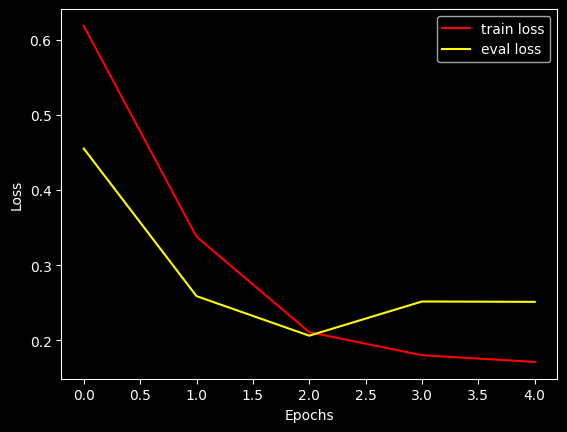

In [18]:
# Plot the loss
import matplotlib.pyplot as plt

plt.plot(loss_logger.train_loss, label="train loss", color='red')
plt.plot(loss_logger.eval_loss, label="eval loss", color='yellow')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

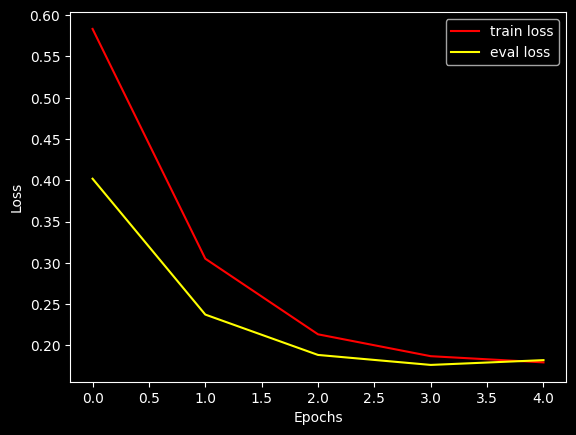

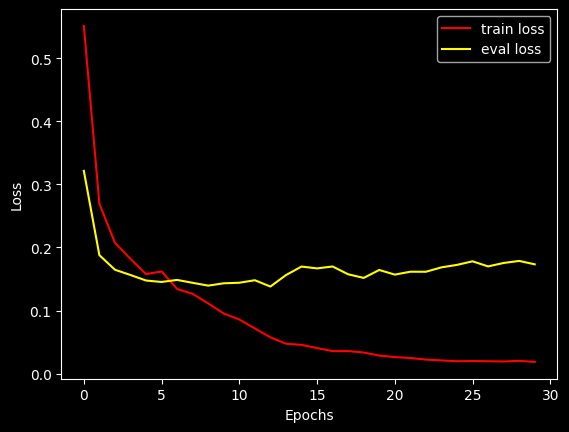

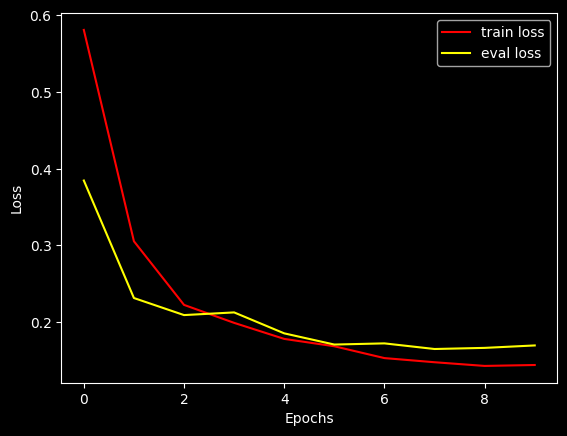

### Saving the trained model

In [10]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# Supongamos que `model` es tu modelo entrenado y `tokenizer` es tu tokenizador
model_dir = "saved_model"

# Guardar el modelo
model.save_pretrained(model_dir)
print(f"Modelo guardado en {model_dir}")

# Guardar el tokenizador (opcional, si tienes un tokenizador)
tokenizer.save_pretrained(model_dir)
print(f"Tokenizador guardado en {model_dir}")

Configuration saved in saved_model/config.json
Model weights saved in saved_model/pytorch_model.bin
tokenizer config file saved in saved_model/tokenizer_config.json
Special tokens file saved in saved_model/special_tokens_map.json


Modelo guardado en saved_model
Tokenizador guardado en saved_model


# Model Evaluation

In [154]:
print(f"eval loss: {loss_logger.eval_loss[-1]}")
print(f"data length: {len(subset_train)}")

eval loss: 0.13890625536441803
data length: 2944


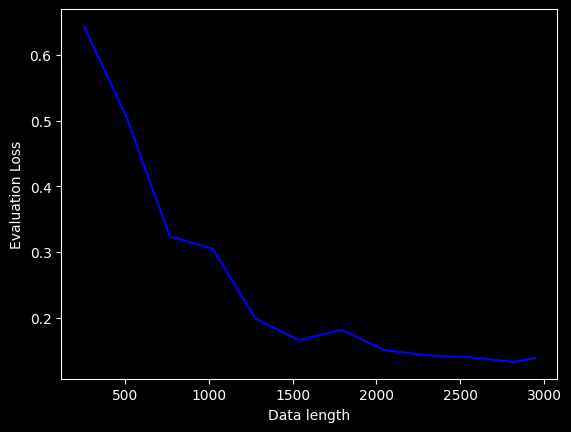

In [ ]:
data_len = [256, 512, 768, 1024, 1280, 1536, 1792, 2048, 2304, 2560, 2816, 2944]
eval_loss = [0.644, 0.504, 0.324, 0.305, 0.199, 0.166, 0.182, 0.151, 0.143, 0.140, 0.133, 0.139]

plt.plot(data_len, eval_loss, label="eval loss", color='blue')
plt.xlabel("Data length")
plt.ylabel("Evaluation Loss")
plt.show()

### Loading the trained model

In [5]:
# reload fine-tuned model
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer
model_dir = "saved_model"

# Crear una nueva instancia del modelo y cargar los pesos guardados
model = AutoModelForSequenceClassification.from_pretrained(model_dir, torch_dtype=torch.bfloat16, device_map="auto", trust_remote_code=True)
print(f"Modelo cargado desde {model_dir}")

# Cargar el tokenizador (opcional, si tienes un tokenizador)
tokenizer = AutoTokenizer.from_pretrained(model_dir, trust_remote_code=True)
print(f"Tokenizador cargado desde {model_dir}")

Explicitly passing a `revision` is encouraged when loading a configuration with custom code to ensure no malicious code has been contributed in a newer revision.
Explicitly passing a `revision` is encouraged when loading a model with custom code to ensure no malicious code has been contributed in a newer revision.
Explicitly passing a `revision` is encouraged when loading a model with custom code to ensure no malicious code has been contributed in a newer revision.


Modelo cargado desde saved_model
Tokenizador cargado desde saved_model


### Dummy experiment
Not trained model evaluation

In [3]:
model_non_trained_head  = AutoModelForSequenceClassification.from_pretrained(checkpoint, torch_dtype=torch.bfloat16, device_map="auto", trust_remote_code=True)

/home/lpedraza/anaconda3/envs/hyena-dna/lib/python3.8/site-packages/huggingface_hub/file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Explicitly passing a `revision` is encouraged when loading a configuration with custom code to ensure no malicious code has been contributed in a newer revision.
Explicitly passing a `revision` is encouraged when loading a model with custom code to ensure no malicious code has been contributed in a newer revision.
Some weights of the model checkpoint at LongSafari/hyenadna-small-32k-seqlen-hf were not used when initializing HyenaDNAForSequenceClassification: ['lm_head.weight']
- This IS expected if you are initializing HyenaDNAForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassifica

In [ ]:
import numpy as np
import torch
from torch.utils.data import Subset

# Verifica si hay una GPU disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)

# Get a sample of test data
subset_test = Subset(ds_test, range(100)) # take a subset of the dataset

data = torch.stack([dat["input_ids"] for dat in subset_test])
target = torch.stack([dat["labels"] for dat in subset_test])
data, target = data.to(device), target.to(device)

# Set the model to evaluation mode and disable gradient computation
model_non_trained_head.eval()
with torch.no_grad():
    output = model_non_trained_head(data)
    
def loss_fn(output, target):
    return torch.nn.functional.cross_entropy(output, target)

# Calculate the loss
loss = loss_fn(output["logits"], target.squeeze())

# Get the predicted class
pred = output["logits"].argmax(dim=1, keepdim=True)

# Calculate accuracy
correct = pred.eq(target.view_as(pred)).sum().item()
accuracy = 100. * correct / len(target)

print(f'Loss: {loss.item():.4f}, Accuracy: {accuracy:.2f}%')

Usando dispositivo: cuda
Loss: 0.7109, Accuracy: 50.00%


The evaluation of the non-trained model shows the expected accuracy of 50% 

### Evaluate the model on trainig data

In [ ]:
import numpy as np
import torch

# Verifica si hay una GPU disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)

# Get a sample of test data
subset_train = Subset(ds_train, range(100)) # take a subset of the dataset

data = torch.stack([dat["input_ids"] for dat in subset_train])
target = torch.stack([dat["labels"] for dat in subset_train])
data, target = data.to(device), target.to(device)

# Set the model to evaluation mode and disable gradient computation
model.eval()
with torch.no_grad():
    output = model(data)
    
def loss_fn(output, target):
    return torch.nn.functional.cross_entropy(output, target)

# Calculate the loss
loss = loss_fn(output["logits"], target.squeeze())

# Get the predicted class
pred = output["logits"].argmax(dim=1, keepdim=True)

# Calculate accuracy
correct = pred.eq(target.view_as(pred)).sum().item()
accuracy = 100. * correct / len(target)

print(f'Loss: {loss.item():.4f}, Accuracy: {accuracy:.2f}%')

Usando dispositivo: cuda
Loss: 0.1592, Accuracy: 97.00%


This is an overfitting experiment:

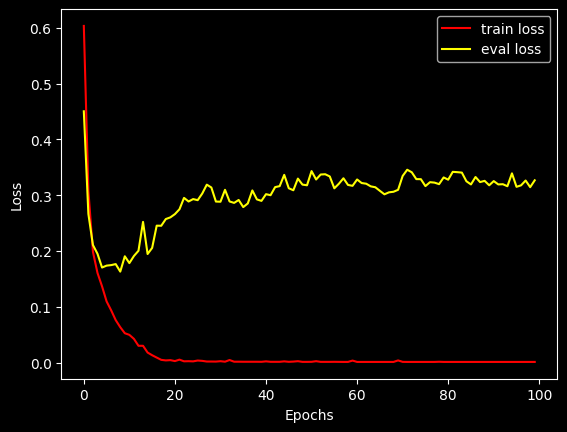

Accuracy 100% on tranig data.

### Evaluate the model on validation data

In [142]:
len(ds_val)

1194

In [6]:
import numpy as np
import torch
from torch.utils.data import DataLoader

# Fijar semillas para reproducibilidad
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)  # Puedes usar cualquier número como semilla

# Verifica si hay una GPU disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)

# Define el tamaño del batch
batch_size = 32  # Ajusta este valor según la memoria disponible

# Crea un DataLoader para procesar los datos en batches
dataloader = DataLoader(ds_val, batch_size=batch_size, shuffle=False)

# Inicializa variables para calcular la pérdida y precisión acumuladas
total_loss = 0.0
correct = 0
total_samples = 0
pred, target = [], []


# Establece el modelo en modo de evaluación
model.eval()

# Desactiva el cálculo de gradientes
with torch.no_grad():
    for batch in dataloader:
        # Extrae los tensores de los diccionarios en el batch
        data_batch = batch['input_ids'].to(device)
        target_batch = batch['labels'].to(device)

        # Realiza la inferencia
        output = model(data_batch)

        # Calcula la pérdida
        loss = torch.nn.functional.cross_entropy(output["logits"], target_batch.squeeze())
        total_loss += loss.item() * len(data_batch)

        # Obtiene la clase predicha
        pred_batch = output["logits"].argmax(dim=1, keepdim=True)

        # Calcula el número de predicciones correctas
        correct += pred_batch.eq(target_batch.view_as(pred_batch)).sum().item()
        total_samples += len(target_batch)

        # Guarda las predicciones y etiquetas
        pred.extend(pred_batch.cpu().numpy())
        target.extend(target_batch.cpu().numpy())
        
# convierte a numpy array
pred = np.array(pred)
target = np.array(target)

# Calcula la pérdida y precisión promedio
average_loss = total_loss / total_samples
accuracy = 100. * correct / total_samples

print(f'Loss: {average_loss:.4f}, Accuracy: {accuracy:.2f}%')


Usando dispositivo: cuda
Loss: 0.1375, Accuracy: 95.39%


In [11]:
ds_val.label_dict

{'gene': 0, 'intergenic': 1}

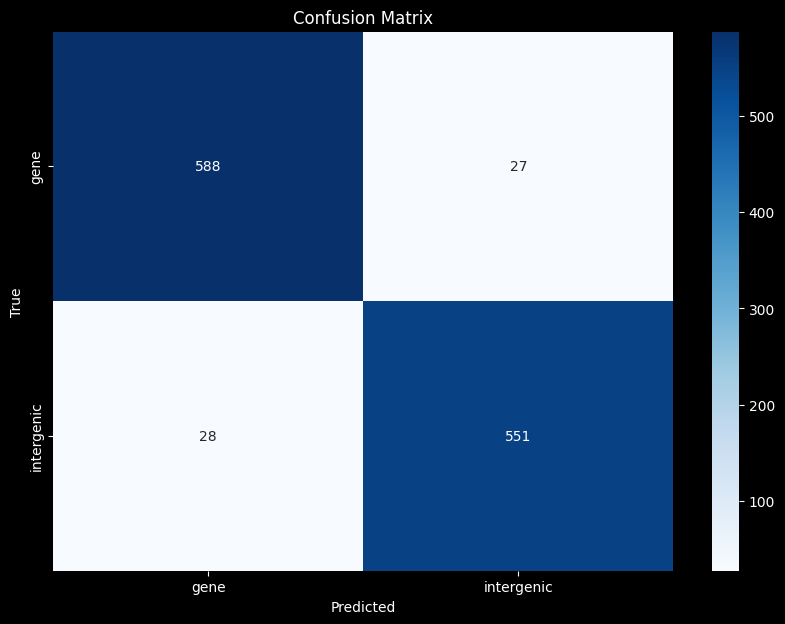

In [6]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(target, pred)

# Plot confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['gene', 'intergenic'], yticklabels=['gene', 'intergenic'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

Confusion matrix without random augmentation for intergenic regions
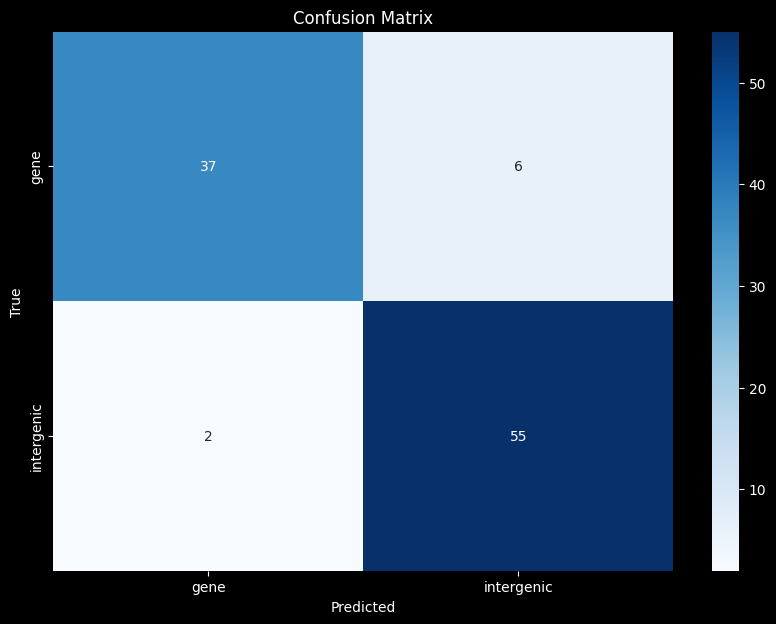

In [7]:
# Identificar falsos positivos y falsos negativos
# Convertir el Subset a una lista
val_ids = np.stack([ds_val[i]['input_ids'].numpy() for i in range(len(ds_val))])
# subset_labels = np.stack([subset_val[i]['labels'].numpy() for i in range(len(subset_val))])

positive_class = ds_val.label_dict['gene']
negative_class = ds_val.label_dict['intergenic']

FP = ((pred != negative_class) & (target == negative_class)).squeeze()
FN = ((pred != positive_class) & (target == positive_class)).squeeze()

# Extraer ejemplos de falsos positivos y falsos negativos
# Usar índices booleanos para extraer ejemplos
ejemplos_fp = val_ids[FP]
target_ej_fp = target[FP]
ejemplos_fn = val_ids[FN]
target_ej_fn = target[FN]

print(f'Falsos positivos: {len(ejemplos_fp)}')
print(f'Falsos negativos: {len(ejemplos_fn)}')

# Opcional: Imprimir algunos ejemplos
print("Ejemplos de falsos positivos:", ejemplos_fp[:5])
print("Ejemplos de falsos negativos:", ejemplos_fn[:5])

Falsos positivos: 28
Falsos negativos: 27
Ejemplos de falsos positivos: [[ 9  7  8 ... 10  7  7]
 [ 7  7  8 ... 10 10 10]
 [ 8  9 10 ...  9 10 10]
 [ 7  8  7 ... 10  7  7]
 [ 7 10 10 ...  9  7 10]]
Ejemplos de falsos negativos: [[ 9 10 10 ... 10  7  7]
 [ 7  8  8 ...  7  9 10]
 [10  9 10 ...  8  7  8]
 [ 7  8  8 ... 10  8 10]
 [ 7 10  7 ... 10  8 10]]


In [14]:
from torch.nn import functional as F
from torch import tensor

# Set the model to evaluation mode and disable gradient computation
# convert array to tensor
ejemplos_fp = tensor(ejemplos_fp)
ejemplos_fn = tensor(ejemplos_fn)
model.eval()
with torch.no_grad():
    output = model(ejemplos_fn.to(device))

# Get the predicted class
probabilidades = F.softmax(output["logits"], dim=-1)

print("Probabilidades:", probabilidades)

Probabilidades: tensor([[0.4355, 0.5664],
        [0.0347, 0.9648],
        [0.2109, 0.7891],
        [0.0933, 0.9062],
        [0.0845, 0.9141],
        [0.0493, 0.9492],
        [0.0884, 0.9102],
        [0.0786, 0.9219],
        [0.3477, 0.6523],
        [0.1426, 0.8555],
        [0.0244, 0.9766],
        [0.3750, 0.6250],
        [0.4590, 0.5430],
        [0.1260, 0.8750],
        [0.4141, 0.5859],
        [0.4609, 0.5391],
        [0.1289, 0.8711],
        [0.0386, 0.9609],
        [0.2266, 0.7734],
        [0.2930, 0.7070],
        [0.0786, 0.9219],
        [0.0145, 0.9844],
        [0.3730, 0.6250],
        [0.0166, 0.9844],
        [0.0154, 0.9844],
        [0.0233, 0.9766],
        [0.3691, 0.6328]], device='cuda:0', dtype=torch.bfloat16)


In [15]:
# Verifico que efectivamente sena falsos positivos y falsos negativos
# Le paso los ejemplos a la función de predicción
data = torch.tensor(ejemplos_fp)
data = data.to(device)

# Set the model to evaluation mode and disable gradient computation
model.eval()
with torch.no_grad():
    output = model(data)

# Get the predicted class
pred = output["logits"].argmax(dim=1, keepdim=True)

# Convertir los tensores a numpy
pred = pred.cpu().numpy().squeeze()

# comparo con los targets
print("Predicciones:", pred)
print("Etiquetas reales:", target[FP].flatten())


Predicciones: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Etiquetas reales: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [18]:
seq_fn = str.join('',tokenizer.convert_ids_to_tokens(ejemplos_fn[0]))
# Buscar la secuencia
result = find_sequence_in_fasta(fasta_file=fa_file_path, query_sequence=seq_fn)
if result:
    chr, start, end, strand = result
    print(f"Coordenadas: chr={chr}, start={start}, end={end}, strand={strand}")

Secuencia encontrada en Chr5 (strand +) en la posición: 4763103
Chr5, seq in strand +: GTTCGTTTCAAGTAAACTCGCCAGGGCAATCAAGGTTTCTGTCTAATTTCTCGTTTACATACACATTAGCATCGTTTTAACTACAATCGAAATTTAGTTGACAAAAAGGTACGTAGTAGTATCCACTTAATTGGAAATTTCTTCTTTTCAAATTTGAAGATTAATTAAGGGACGTACGTCTCAAAGTAAAATAAAAATAAAAATAAACTATACTCCTTCTAACCTACCGTTATCGTTCGACTCTTTTAATTTTAGCTTATATCTTGAACCAACATTTAATAAGATTATATGAACAATTCACAAAAGAAAATCCAAAATTTTGCTTAGGAAGAAATTGAAGAAACATTTAAAACATTAATCGATGCATATAGAGTTTTTAAGCATATACATTAGAGTTAACCCAAGAAAGTTCACCTAATTAATAGACTTAGCCAATCATACACTACCACATCAACAACTTTTAATCTAAGACTGTTGATGTATTAGTGTTTGATCAGCTTTGAAAATAACAAAACATAAACGAATACTAAAATAACAAAAGCAGAAAACACATCAAAAACAGTGTCCATCTATAAAGTCCATCATGTTGGTGAGTGTGCTAAGCTCAAACTCATCCTCATGAACCCAAAGTGAACTCAAGTAGTTACTTCCTTGATGATCTTCTTGAATTTCATCTCCGAGGATATTATTGTTATCGACAATATTCGAGATTTTCGTTTCTTCTGATGTTTCGGTAGGATTCGGGAGATTGATTTGATAAACAATATCACCATTGCTCTGTTTGGTTTTCTGATCTTTGATTCCGAGTTTCTTACTAAGATGCGTGTTCCAATAGTTCTTCACTTGATTATCCGTTCGACCCGGCACTCTTTTAGCAATTAAAGACCACCTAATTAAACACACAGATAAACAA

In [11]:
# return chr, start, end, strand for each false negative example
fn_coords = []
for i in range(len(ejemplos_fn)):
    seq_fn = str.join('',tokenizer.convert_ids_to_tokens(ejemplos_fn[i]))
    result = find_sequence_in_fasta(fasta_file=fa_file_path, query_sequence=seq_fn)
    if result:
        chr, start, end, strand = result
        fn_coords.append((chr, start, end, strand))
    else:
        fn_coords.append(None)  

Secuencia encontrada en Chr5 (strand +) en la posición: 4763103
Chr5, seq in strand +: GTTCGTTTCAAGTAAACTCGCCAGGGCAATCAAGGTTTCTGTCTAATTTCTCGTTTACATACACATTAGCATCGTTTTAACTACAATCGAAATTTAGTTGACAAAAAGGTACGTAGTAGTATCCACTTAATTGGAAATTTCTTCTTTTCAAATTTGAAGATTAATTAAGGGACGTACGTCTCAAAGTAAAATAAAAATAAAAATAAACTATACTCCTTCTAACCTACCGTTATCGTTCGACTCTTTTAATTTTAGCTTATATCTTGAACCAACATTTAATAAGATTATATGAACAATTCACAAAAGAAAATCCAAAATTTTGCTTAGGAAGAAATTGAAGAAACATTTAAAACATTAATCGATGCATATAGAGTTTTTAAGCATATACATTAGAGTTAACCCAAGAAAGTTCACCTAATTAATAGACTTAGCCAATCATACACTACCACATCAACAACTTTTAATCTAAGACTGTTGATGTATTAGTGTTTGATCAGCTTTGAAAATAACAAAACATAAACGAATACTAAAATAACAAAAGCAGAAAACACATCAAAAACAGTGTCCATCTATAAAGTCCATCATGTTGGTGAGTGTGCTAAGCTCAAACTCATCCTCATGAACCCAAAGTGAACTCAAGTAGTTACTTCCTTGATGATCTTCTTGAATTTCATCTCCGAGGATATTATTGTTATCGACAATATTCGAGATTTTCGTTTCTTCTGATGTTTCGGTAGGATTCGGGAGATTGATTTGATAAACAATATCACCATTGCTCTGTTTGGTTTTCTGATCTTTGATTCCGAGTTTCTTACTAAGATGCGTGTTCCAATAGTTCTTCACTTGATTATCCGTTCGACCCGGCACTCTTTTAGCAATTAAAGACCACCTAATTAAACACACAGATAAACAA

In [12]:
fn_coords

[('Chr5', 4763103, 4765103, '+'),
 ('Chr1', 6266609, 6268609, '+'),
 ('Chr4', 1569837, 1571837, '+'),
 ('Chr5', 14973353, 14975353, '+'),
 ('Chr4', 16528643, 16530643, '+'),
 ('Chr5', 22231199, 22233199, '+'),
 ('Chr3', 18200587, 18202587, '+'),
 ('Chr4', 9764346, 9766346, '+'),
 ('Chr3', 6431314, 6433314, '+'),
 ('Chr5', 8310463, 8312463, '+'),
 ('Chr2', 9714621, 9716621, '+'),
 ('Chr2', 187608, 189608, '+'),
 ('Chr5', 17984479, 17986479, '+'),
 ('Chr5', 24946590, 24948590, '+'),
 ('Chr4', 414204, 416204, '+'),
 ('Chr5', 7488947, 7490947, '+'),
 ('Chr1', 18550891, 18552891, '+'),
 ('Chr3', 5684317, 5686317, '+'),
 ('Chr1', 20910701, 20912701, '+'),
 ('Chr1', 19621238, 19623238, '+'),
 ('Chr4', 17849538, 17851538, '+'),
 ('Chr1', 6235895, 6237895, '+'),
 ('Chr1', 12433046, 12435046, '+'),
 ('Chr1', 12932024, 12934024, '+'),
 ('Chr4', 4884442, 4886442, '+'),
 ('Chr1', 21241579, 21243579, '+'),
 ('Chr1', 12162112, 12164112, '+')]

In [8]:
seq_fp = str.join('',tokenizer.convert_ids_to_tokens(ejemplos_fp[0]))
# Buscar la secuencia
result = find_sequence_in_fasta(fasta_file=fa_file_path, query_sequence=seq_fp)
if result:
    chr, start, end, strand = result
    print(f"Coordenadas: chr={chr}, start={start}, end={end}, strand={strand}")

Secuencia encontrada en Chr4 (strand +) en la posición: 8407897
Chr4, seq in strand +: GACCCATTATTACTGAGACTATATTATTATTGGCCCATTAGTATTCACTTTTTCTCTATTTTCTTTTAAATATATTTTCAGAAACTAATTAATTTTTCATTTTAAGATTACTAATTTCATATATTTAAAAACTTTGAAAATTTGATTCTCAAATATTTAAAATTAGATTAAACTTTTTAATCATATTCGAAAATATACTTTTTCTTCTCTAAATTGATAGAAAAATACAAATTAATATATATTTCCTTTTAATTATTTAATCTAATTAGATTAAAAAAATATCTCCATTGAAATCTGGTCGTCTGTCACGTGTTGTGATTATGTTTTTTTTTTACTCAAACATGCTTCTCATATTAAATAGGGATTAAAATCCCGGTATAATGCGTTTGTGATTACATTAGGAATGAGGTTGTAAAAATGCGACAAAGCATCAGATGGTATTCTATGTTTCGCTAAGATATCCGCCGCTTTGTTGTGATCTCTTCGAACCCAAGTAAACTGGCAGTCATTAAACTTGTCTCTCCAAATGCGTGCTTCCCTAATCCAATTAAAAATATTGAAATTGTGTTGCCGACCATGAAGCAGTTCCACCACTGTTTTGTTATCGCCTTCAAAACATACTCTTGTATATCCCTTAATCCAACAGCTTTGCATTGCAAGAATTAGTGCCTGAAATTCGCTTTCCATAGCTGTGTTTACATGTCTTCCTTTAGCTTGACCTGCACCTCTAAAGGTGCCTCTGTCGTCTCTAATCACCTATCCTGCACTAGCCGGTTGTCCGTTGATAAAGCTACCATCATAGTTGCATTTGATCCAGTTTGTATTCGGCTTCATCCAATGATATTCGCCTTGAAAACCAACGTTCTGAAATTGCGGAGGGTTCGTCATTCCCAAACTTCTTTCATCTTGATCA

In [13]:
# return chr, start, end, strand for each false positive example
from numpy import mat


fp_coords = []
for i in range(len(ejemplos_fp)):
    seq_fp = str.join('',tokenizer.convert_ids_to_tokens(ejemplos_fp[i]))
    result = find_sequence_in_fasta(fasta_file=fa_file_path, query_sequence=seq_fp)
    if result:
        chr, start, end, strand = result
        fp_coords.append((chr, start, end, strand))
    else:
        fp_coords.append(None)  

Secuencia encontrada en Chr4 (strand +) en la posición: 8407897
Chr4, seq in strand +: GACCCATTATTACTGAGACTATATTATTATTGGCCCATTAGTATTCACTTTTTCTCTATTTTCTTTTAAATATATTTTCAGAAACTAATTAATTTTTCATTTTAAGATTACTAATTTCATATATTTAAAAACTTTGAAAATTTGATTCTCAAATATTTAAAATTAGATTAAACTTTTTAATCATATTCGAAAATATACTTTTTCTTCTCTAAATTGATAGAAAAATACAAATTAATATATATTTCCTTTTAATTATTTAATCTAATTAGATTAAAAAAATATCTCCATTGAAATCTGGTCGTCTGTCACGTGTTGTGATTATGTTTTTTTTTTACTCAAACATGCTTCTCATATTAAATAGGGATTAAAATCCCGGTATAATGCGTTTGTGATTACATTAGGAATGAGGTTGTAAAAATGCGACAAAGCATCAGATGGTATTCTATGTTTCGCTAAGATATCCGCCGCTTTGTTGTGATCTCTTCGAACCCAAGTAAACTGGCAGTCATTAAACTTGTCTCTCCAAATGCGTGCTTCCCTAATCCAATTAAAAATATTGAAATTGTGTTGCCGACCATGAAGCAGTTCCACCACTGTTTTGTTATCGCCTTCAAAACATACTCTTGTATATCCCTTAATCCAACAGCTTTGCATTGCAAGAATTAGTGCCTGAAATTCGCTTTCCATAGCTGTGTTTACATGTCTTCCTTTAGCTTGACCTGCACCTCTAAAGGTGCCTCTGTCGTCTCTAATCACCTATCCTGCACTAGCCGGTTGTCCGTTGATAAAGCTACCATCATAGTTGCATTTGATCCAGTTTGTATTCGGCTTCATCCAATGATATTCGCCTTGAAAACCAACGTTCTGAAATTGCGGAGGGTTCGTCATTCCCAAACTTCTTTCATCTTGATCA

In [14]:
fp_coords

[('Chr4', 8407897, 8409897, '+'),
 ('Chr3', 20208784, 20210784, '+'),
 ('Chr2', 7631927, 7633927, '+'),
 ('Chr1', 17595354, 17597354, '+'),
 None,
 None,
 ('Chr1', 12118862, 12120862, '+'),
 ('Chr5', 23397651, 23399651, '+'),
 ('Chr1', 22917364, 22919364, '+'),
 ('Chr5', 21926497, 21928497, '+'),
 ('Chr4', 6449999, 6451999, '+'),
 ('Chr3', 22561717, 22563717, '+'),
 ('Chr2', 7246070, 7248070, '+'),
 ('Chr5', 16407931, 16409931, '+'),
 ('Chr2', 10297598, 10299598, '+'),
 None,
 ('Chr2', 5861312, 5863312, '+'),
 ('Chr4', 8635592, 8637592, '+'),
 ('Chr1', 21381462, 21383462, '+'),
 ('Chr4', 7921232, 7923232, '+'),
 ('Chr5', 15097319, 15099319, '+'),
 ('Chr2', 13172169, 13174169, '+'),
 None,
 ('Chr4', 11405236, 11407236, '+'),
 ('Chr2', 14839917, 14841917, '+'),
 ('Chr1', 2212719, 2214719, '+'),
 ('Chr5', 23987383, 23989383, '+'),
 ('Chr1', 23850143, 23852143, '+')]

In [17]:
# save in file the false negatives and false positives coordinates
import csv

with open('/home/lpedraza/Desktop/fn_coords.csv', mode='w') as file:
    writer = csv.writer(file)
    writer.writerow(['chr', 'start', 'end', 'strand'])
    for row in fn_coords:
        writer.writerow(row)

with open('/home/lpedraza/Desktop/fp_coords.csv', mode='w') as file:
    writer = csv.writer(file)
    writer.writerow(['chr', 'start', 'end', 'strand'])
    for row in fp_coords:
        if row:
            writer.writerow(row)


In [35]:
# none rows in fn_coords
lost_seqs = [str.join('',tokenizer.convert_ids_to_tokens(ejemplos_fp[i])) for i in range(len(fp_coords)) if fp_coords[i] is None]

In [45]:
import csv

with open('/home/lpedraza/Desktop/fp_lost_seqs.csv', mode='w') as file:
    writer = csv.writer(file)
    for row in lost_seqs:
        writer.writerow([row])